# About dataset

In [160]:
import pandas as pd

In [161]:
df = pd.read_csv('Mall_Customers.csv')

In [162]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [163]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


# Find shape of the dataset

In [164]:
df.shape

(200, 5)

In [165]:
print('Number of rows: ', df.shape[0])
print('Number of columns: ', df.shape[1])

Number of rows:  200
Number of columns:  5


# Get Information about dataset

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Check null values of dataset

In [167]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Overall statistics of dataset

In [168]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Kmeans clustering

In [169]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [170]:
X= df[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [171]:
from sklearn.cluster import KMeans

In [172]:
kmeans = KMeans()
kmeans.fit(X)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [173]:
kmeans = KMeans()
kmeans.fit_predict(X)

array([7, 5, 3, 5, 7, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 7, 5, 7, 5, 7, 5,
       3, 5, 3, 5, 7, 1, 7, 5, 3, 5, 3, 5, 3, 5, 3, 5, 7, 5, 7, 5, 7, 1,
       7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 0, 2, 4, 2, 0, 2, 0, 2,
       4, 2, 0, 2, 0, 2, 0, 2, 0, 2, 4, 2, 0, 2, 4, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2,
       6, 2], dtype=int32)

# Elbow method to find optimal number of clusters

In [174]:
list = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    list.append(kmeans.inertia_)

list

[269981.28,
 181363.595959596,
 106348.37306211119,
 73880.64496247197,
 44454.47647967974,
 38858.9599751439,
 33610.528526645765,
 26654.78709105433,
 21826.93630323165,
 20338.03288508182]

In [175]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Inertia')

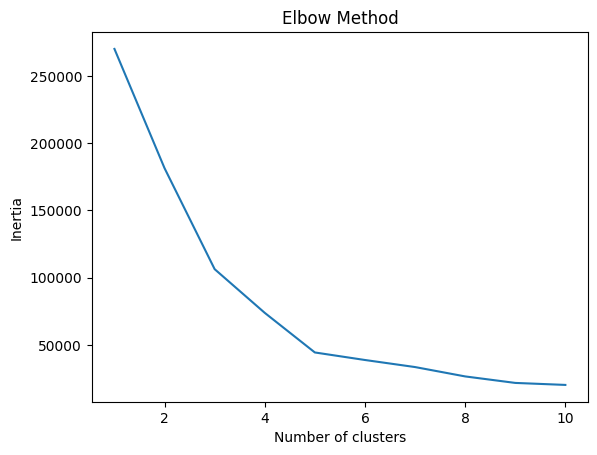

In [176]:
plt.plot(range(1,11),list)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# Model training

In [177]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)' ]]

In [178]:
k_means = KMeans(n_clusters=5, random_state=42)
y_means = k_means.fit_predict(X)

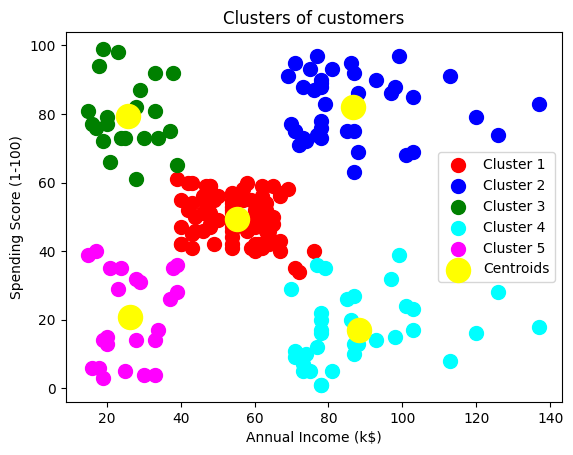

In [179]:
plt.scatter(X.iloc[y_means == 0,0], X.iloc[y_means == 0, 1], s=100,  c='red', label='Cluster 1')
plt.scatter(X.iloc[y_means == 1,0], X.iloc[y_means == 1, 1], s=100,  c='blue', label='Cluster 2')
plt.scatter(X.iloc[y_means == 2,0], X.iloc[y_means == 2, 1], s=100,  c='green', label='Cluster 3')
plt.scatter(X.iloc[y_means == 3,0], X.iloc[y_means == 3, 1], s=100,  c='cyan', label='Cluster 4')
plt.scatter(X.iloc[y_means == 4,0], X.iloc[y_means == 4, 1], s=100,  c='magenta', label='Cluster 5')
plt.scatter(k_means.cluster_centers_[:,0], k_means.cluster_centers_[:,1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [180]:
k_means.predict([[15, 39]])

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

# Save model

In [181]:
import joblib

In [182]:
joblib.dump(k_means, 'customer_segmentation_model')


['customer_segmentation_model']

In [185]:
model = joblib.load('customer_segmentation_model')

In [186]:
model.predict([[15, 39]])

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

# GUI

In [187]:
from tkinter import *
import joblib

In [194]:
model = joblib.load("customer_segmentation_model")

def predict_cluster():
    try:
        annual_income = int(annual_income_entry.get())
        spending_score = int(spending_score_entry.get())

        result = model.predict([[annual_income, spending_score]])
        cluster = result[0]

        if cluster == 0:
            text = "Customer with medium income and medium spending score"
        elif cluster == 1:
            text = "Customer with high income and high spending score"
        elif cluster == 2:
            text = "Customer with low income and high spending score"
        elif cluster == 3:
            text = "Customer with high income and low spending score"
        elif cluster == 4:
            text = "Customer with low income and low spending score"
        else:
            text = "Unknown cluster"

        result_label.config(text=text)

    except ValueError:
        result_label.config(text="Please enter valid numbers")

master = Tk()
master.title("Customer Segmentation")
master.configure(bg="lightblue")
master.geometry("500x300")

label = Label(
    master,
    text="Enter Annual Income(k$) and Spending Score(1-100)",
    bg="lightblue",
    fg="black",
    font=("Arial", 14)
)
label.grid(row=0, column=0, columnspan=2, pady=10)

Label(master, text="Annual Income (k$)", bg="lightblue").grid(row=1, column=0, padx=10, pady=10)
Label(master, text="Spending Score (1-100)", bg="lightblue").grid(row=2, column=0, padx=10, pady=10)

annual_income_entry = Entry(master)
spending_score_entry = Entry(master)

annual_income_entry.grid(row=1, column=1)
spending_score_entry.grid(row=2, column=1)

Button(
    master,
    text="Predict Cluster",
    command=predict_cluster,
    bg="green",
    fg="white"
).grid(row=3, column=0, columnspan=2, pady=20)

result_label = Label(
    master,
    text="",
    bg="lightblue",
    fg="blue",
    font=("Arial", 12, "bold"),
    wraplength=400
)
result_label.grid(row=4, column=0, columnspan=2, pady=10)

master.mainloop()